# Do Everything


2025-10-13 16:04:11.617420: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-10-13 16:04:11.618804: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-13 16:04:11.700105: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step


2025-10-13 16:04:15.107669: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Image Quantization Parameters: scale 227.4644909149226, zero_point -127
Image average 0.441671095610694, max_difference 0.558328904389306


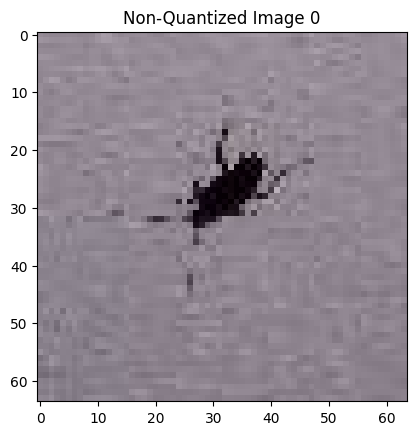

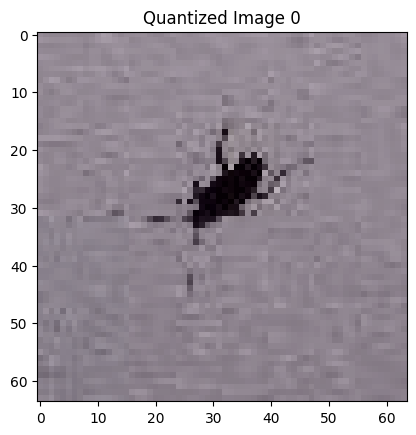

Processing layer 0: conv2d with activation shape (1000, 60, 60, 32)
Layer conv2d Average: 0.03326684075236386, Max Difference: 1.6906633989250652, Scale: 75.1184417198287, Zero Point: -127
Layer conv2d Quantization Parameters: input_scale 75.1184417198287, input_zero_point -127, weight_scale 419.3088582098988, bias_scale 31497.828028048196
Processing layer 1: conv2d_1 with activation shape (1000, 56, 56, 32)
Layer conv2d_1 Average: 0.031110250320515884, Max Difference: 4.0731397039031165, Scale: 31.17987823454749, Zero Point: -127
Layer conv2d_1 Quantization Parameters: input_scale 31.17987823454749, input_zero_point -127, weight_scale 260.8992077660963, bias_scale 8134.80552963679
Processing layer 2: conv2d_2 with activation shape (1000, 28, 28, 32)
Layer conv2d_2 Average: 0.052138304615708994, Max Difference: 4.052111649607924, Scale: 31.341683295495653, Zero Point: -127
Layer conv2d_2 Quantization Parameters: input_scale 31.341683295495653, input_zero_point -127, weight_scale 183.42

In [ ]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
from tiny_imagenet import TinyImagenetDataset
import matplotlib.pyplot as plt
from pathlib import Path


# model_path = os.path.abspath(""/home/<NETID>/path/to/your/lab1/CNN_TinyImageNet.h5)" # Uncomment this to use a non-relative path
model_path = os.path.abspath("CNN_TinyImageNet.h5")
model = tf.keras.models.load_model(model_path)

layer_outputs = [layer.output for layer in model.layers]
layer_inputs = [layer.input for layer in model.layers]
feature_map_model = tf.keras.Model(inputs=model.inputs, outputs=layer_outputs)

### build image datasets ###
tiny_imagenet_builder = TinyImagenetDataset()
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

ds = tiny_imagenet_builder.as_dataset()
ds_train, ds_val = ds["train"], ds["validation"]
assert(isinstance(ds_train, tf.data.Dataset))
assert(isinstance(ds_val, tf.data.Dataset))
ds_train = ds_train.shuffle(1000).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.shuffle(1000).prefetch(tf.data.AUTOTUNE)

# We need to read the "human readable" labels so we can translate with the numeric values
# Read the labels file (words.txt)
with open(os.path.abspath('wnids.txt'), 'r') as f:
    wnids = [x.strip() for x in f]

# Map wnids to integer labels
wnid_to_label = {wnid: i for i, wnid in enumerate(wnids)}
label_to_wnid = {v: k for k, v in wnid_to_label.items()}

# Use words.txt to get names for each class
with open(os.path.abspath('words.txt'), 'r') as f:
    wnid_to_words = dict(line.split('\t') for line in f)
    for wnid, words in wnid_to_words.items():
        wnid_to_words[wnid] = [w.strip() for w in words.split(',')]

class_names = [str(wnid_to_words[wnid]) for wnid in wnids]

val_data = ds_val.take(1000).batch(1)


# build validation dataset
val_imgs = []
for index, img_data in enumerate(val_data):
  val_imgs.append(img_data)

# non quantized prediction
for batch in ds_val.batch(1000).take(1):
    all_activations = feature_map_model.predict(tf.cast(batch["image"], tf.float32) / 255.0)

##########################################
# Helper Functions
##########################################

# Change this for different quantization ranges
# int8 is -128 to 127
maxInt = 127
minInt = -128

###########################################
# Getters for Quantization Parameters #
############################################

def get_average(flat_input):
    """ Get the average value of the input """
    sum = 0
    for input in flat_input:
        sum += input
    average = sum / len(flat_input)
    return average

def get_max_difference(flat_input, average):
    """ Get the maximum absolute difference from the average value """
    max_diff = 0.0
    for input in flat_input:
        diff = abs(input - average)
        if diff > max_diff:
            max_diff = diff
    return max_diff

def get_max_weight(weights):
    """ Get the maximum absolute weight value """
    max_weight = 0
    flat_weights = weights.flatten()
    for weight in flat_weights:
        abs_weight = abs(weight)
        if abs_weight > max_weight:
            max_weight = abs_weight
    return max_weight

def get_input_zero_point(avgIx):
    """ Get the input zero point """
    zp = -1 * round(maxInt - (avgIx))
    if zp < minInt:
        zp = minInt
    elif zp > maxInt:
        zp = maxInt
    return zp

def get_input_scale(maxIx):
    """ Get the input scale """
    scale = maxInt / maxIx
    return scale

def get_weight_scale(maxIw):
    """ Get the weight scale """
    scale = maxInt / maxIw
    return scale

def get_bias_scale(scale_input, scale_weight):
    """ Get the bias scale """
    scale_bias = scale_input * scale_weight
    return scale_bias

##########################################
# Computational Functions #
##########################################

def quantize_inputs(inputs, scale, zero_point):
    """ Quantize the input activations """
    quantized = np.round(inputs * scale) + zero_point
    quantized = np.clip(quantized, minInt, maxInt).astype(np.int8)
    return quantized

def quantize_weights(weights, scale):
    """ Quantize the weights """
    quantized = np.round(weights * scale)
    quantized = np.clip(quantized, minInt, maxInt).astype(np.int8) # SHOULD NEVER EXCEED ANYWAYS
    return quantized

def compute_wi_zp_sum(weights, zero_point):
    """ Compute the sum of weights times input zero point """
    sum = 0
    flat_weights = weights.flatten()
    for weight in flat_weights:
        sum += weight * zero_point
    return sum

def quantize_biases(biases, scale_bias, zero_point_sum):
    """ Quantize the biases """
    quantized = np.round(biases * scale_bias) + zero_point_sum # Compute Sum wi * zp_i ahead of time!
    quantized = np.clip(quantized, -2147483648, 2147483647).astype(np.int32)  # int32 range, TODO change if not int8
    return quantized


#########################################
# Save Values to binary files #
#########################################

def output_to_bin(filename, path, flattened_data):
    """ Save the flattened data to a binary file """
    full_path = os.path.join(img_dir, path)
    full_path = os.path.join(full_path, filename + ".bin")
    flattened_data.tofile(full_path)
    #print(f"Saved {filename} to {full_path}")
    return


#########################################
# Quantize Images and Save to Binary Files #
#########################################

img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

for subdir in ['quant_val', 'quant_weights', 'layer_outputs']:
    subdir_path = os.path.join(img_dir, subdir)
    if not os.path.exists(subdir_path):
        Path(subdir_path).mkdir()

# Note: compare quantized outputs to non-quantized outputs for validation

############################################
# Do image inputs #
###########################################

flat_images = []
for i, img_data in enumerate(val_imgs):
    img = tf.cast(img_data['image'], tf.float32) / 255.0  # Normalize to [0, 1]
    flat_img = img.numpy().flatten()
    flat_images.append(flat_img)

flat_flat_images = np.concatenate(flat_images)

image_average = get_average(flat_flat_images)

image_max_diff = get_max_difference(flat_flat_images, image_average)

image_scale = get_input_scale(image_max_diff)

image_zero_point = get_input_zero_point(image_average)

print(f"Image Quantization Parameters: scale {image_scale}, zero_point {image_zero_point}")
print(f"Image average {image_average}, max_difference {image_max_diff}")

# Quantize and save images
quantized_images = []

for i, image in enumerate(flat_images):
    quantized_image = quantize_inputs(image, image_scale, image_zero_point)
    quantized_images.append(quantized_image)
    output_to_bin(f"image_{i}", "quant_val", quantized_image)

# print one non-quantized image as a grid/image
plt.imshow(flat_images[0].reshape(64, 64, 3), cmap='gray')
plt.title("Non-Quantized Image 0")
plt.show()

#print one quantized image as a grid/image, dequantize first
dequantized_image = (quantized_images[0].astype(np.float32) - image_zero_point) / image_scale
plt.imshow(dequantized_image.reshape(64, 64, 3), cmap='gray')
plt.title("Quantized Image 0")
plt.show()


##########################################
# Layer by Layer quantization #
##########################################

for i, layer_name in enumerate([layer.name for layer in model.layers if 'conv' in layer.name or 'dense' in layer.name]):
    layer = model.get_layer(layer_name)
    layer_activation = all_activations[i]
    print(f"Processing layer {i}: {layer_name} with activation shape {layer_activation.shape}")
    single_image_activations = layer_activation[0]  # Take the first image's activations for comparison

    # 1. Get quantization parameters for activations (with whole batch)
    flat_input = np.concatenate([layer_activation[j].flatten() for j in range(layer_activation.shape[0])])
    input_average = get_average(flat_input)
    input_max_diff = get_max_difference(flat_input, input_average)
    scale = get_input_scale(input_max_diff)
    zero_point = get_input_zero_point(input_average)

    print(f"Layer {layer_name} Average: {input_average}, Max Difference: {input_max_diff}, Scale: {scale}, Zero Point: {zero_point}")

    # 2. Quantize the input activations for first image
    first_image_activation = layer_activation[0]
    quantized_activation = quantize_inputs(first_image_activation, scale, zero_point)

    # 3. get weights and bias parameters
    weights = layer.get_weights()[0]  # Get weights
    max_weight = get_max_weight(weights)
    weight_scale = get_weight_scale(max_weight)
    biases = layer.get_weights()[1] if len(layer.get_weights()) > 1 else np.zeros(layer.output_shape[-1])
    bias_scale = get_bias_scale(scale, weight_scale)
    wi_zp_sum = compute_wi_zp_sum(weights, zero_point)
    quantized_biases = quantize_biases(biases, bias_scale, wi_zp_sum)
    quantized_weights = quantize_weights(weights, weight_scale)

    
    # Save quantized activations
    output_to_bin(f"{layer_name}_output", "layer_outputs", quantized_activation.flatten())

    # Save quantized weights and biases
    output_to_bin(f"{layer_name}_weights", "quant_weights", quantized_weights.flatten())
    output_to_bin(f"{layer_name}_biases", "quant_weights", quantized_biases.flatten())

    # Save quantization parameters
    params = np.array([scale, zero_point, weight_scale, bias_scale], dtype=np.float32)
    print(f"Layer {layer_name} Quantization Parameters: input_scale {scale}, input_zero_point {zero_point}, weight_scale {weight_scale}, bias_scale {bias_scale}")
    output_to_bin(f"{layer_name}_params", "quant_weights", params)

# output the final layer output to bin
output_to_bin("softmax_output", "layer_outputs", all_activations[len(all_activations)])
